# SHAP for Regession - Support Vector Regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap
import time 

from tabulate import tabulate
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.svm import SVR
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

total_start_time = time.time()
warnings.filterwarnings('ignore')


In [3]:
# Import Data
# set the fule URl and filename
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'
filename = 'wine.csv'

# Check if the file is in the current directory
try:
    wine = pd.read_csv(filename)
except FileNotFoundError:
    print(f'Downloading {filename}from {url} ...')
    wine = pd.read_csv(url, sep=";")
    wine.to_csv(filename, index=False)
    print('Download complete!')

In [4]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [5]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [6]:
summary = wine.describe().transpose().round(2)
summary = summary.drop("count", axis=1)

# create a markdown table
markdown_table = tabulate(
    summary, headers='keys', tablefmt='pipe'
)
print(markdown_table)

|                      |   mean |   std |   min |    25% |    50% |    75% |    max |
|:---------------------|-------:|------:|------:|-------:|-------:|-------:|-------:|
| fixed acidity        |   6.85 |  0.84 |  3.8  |   6.3  |   6.8  |   7.3  |  14.2  |
| volatile acidity     |   0.28 |  0.1  |  0.08 |   0.21 |   0.26 |   0.32 |   1.1  |
| citric acid          |   0.33 |  0.12 |  0    |   0.27 |   0.32 |   0.39 |   1.66 |
| residual sugar       |   6.39 |  5.07 |  0.6  |   1.7  |   5.2  |   9.9  |  65.8  |
| chlorides            |   0.05 |  0.02 |  0.01 |   0.04 |   0.04 |   0.05 |   0.35 |
| free sulfur dioxide  |  35.31 | 17.01 |  2    |  23    |  34    |  46    | 289    |
| total sulfur dioxide | 138.36 | 42.5  |  9    | 108    | 134    | 167    | 440    |
| density              |   0.99 |  0    |  0.99 |   0.99 |   0.99 |   1    |   1.04 |
| pH                   |   3.19 |  0.15 |  2.72 |   3.09 |   3.18 |   3.28 |   3.82 |
| sulphates            |   0.49 |  0.11 |  0.22 |   0.

## Fit a Regression Model with Support Vector Regression

In [8]:
y = wine['quality']
X = wine.drop('quality', axis=1)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

In [10]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())  # default kernel='rbf'
])

In [11]:
"""
param_grid = {
    "svr__kernel": ["rbf", "linear"],
    "svr__C": [0.3, 1, 3, 10, 30],
    "svr__gamma": ["scale", 0.1, 0.03, 0.01],   # only used for 'rbf'
    "svr__epsilon": [0.01, 0.1, 0.3, 1.0],
} """

'\nparam_grid = {\n    "svr__kernel": ["rbf", "linear"],\n    "svr__C": [0.3, 1, 3, 10, 30],\n    "svr__gamma": ["scale", 0.1, 0.03, 0.01],   # only used for \'rbf\'\n    "svr__epsilon": [0.01, 0.1, 0.3, 1.0],\n} '

In [12]:
param_grid = {
    "svr__kernel": ["rbf"],
    "svr__C": [2, 3, 4],
    "svr__gamma": [0.1, 0.2, 0.3],   # only used for 'rbf'
    "svr__epsilon": [0.29, 0.31, 0.3],
}

In [13]:
cv = KFold(n_splits=10, shuffle=True, random_state=11)

In [14]:
search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  # RMSE (negative because "higher is better" convention)
    cv=cv,
    n_jobs=-1
)

In [15]:
search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=11, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svr', SVR())]),
             n_jobs=-1,
             param_grid={'svr__C': [2, 3, 4], 'svr__epsilon': [0.29, 0.31, 0.3],
                         'svr__gamma': [0.1, 0.2, 0.3],
                         'svr__kernel': ['rbf']},
             scoring='neg_root_mean_squared_error')

In [16]:
w = search.best_estimator_
print(w)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svr', SVR(C=2, epsilon=0.29, gamma=0.3))])


In [17]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

In [18]:
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Best params:", search.best_params_)
print(f"Test RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")

Best params: {'svr__C': 2, 'svr__epsilon': 0.29, 'svr__gamma': 0.3, 'svr__kernel': 'rbf'}
Test RMSE: 0.649 | MAE: 0.491 | R²: 0.475


## SHAP Values

In [20]:
explainer = shap.Explainer(best_model.predict, X_train)

In [21]:
shap_values = explainer(X_test)

PermutationExplainer explainer: 981it [2:49:58, 10.41s/it]                                                             


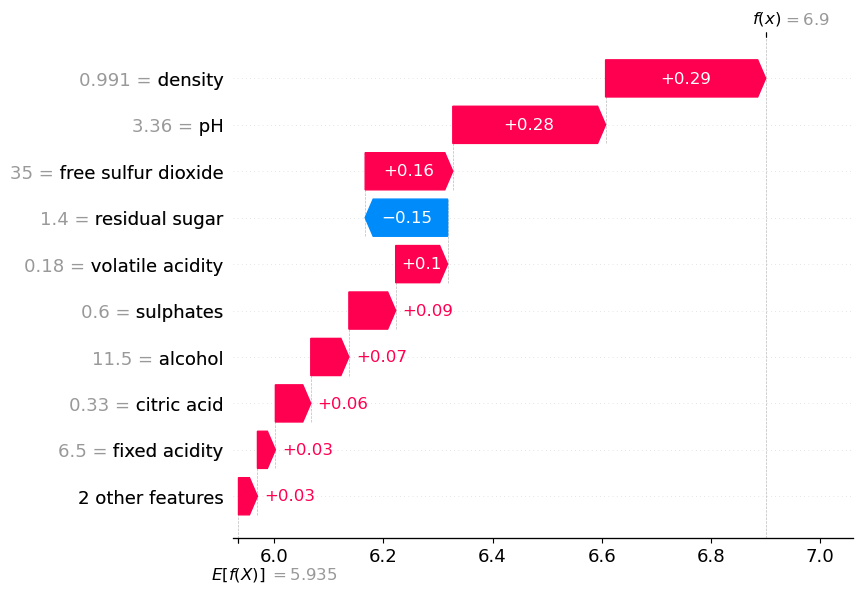

In [22]:
shap.plots.waterfall(shap_values[0])

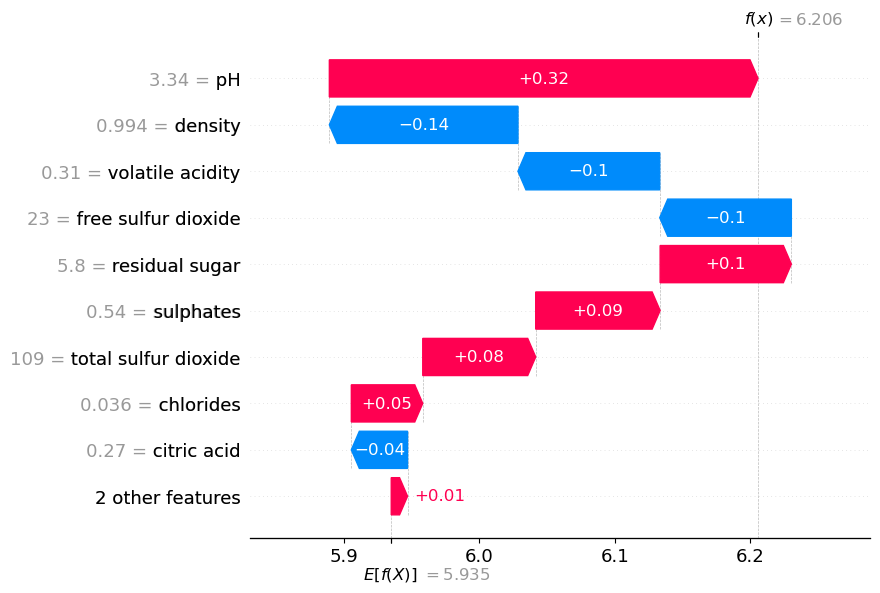

In [23]:
shap.plots.waterfall(shap_values[1])

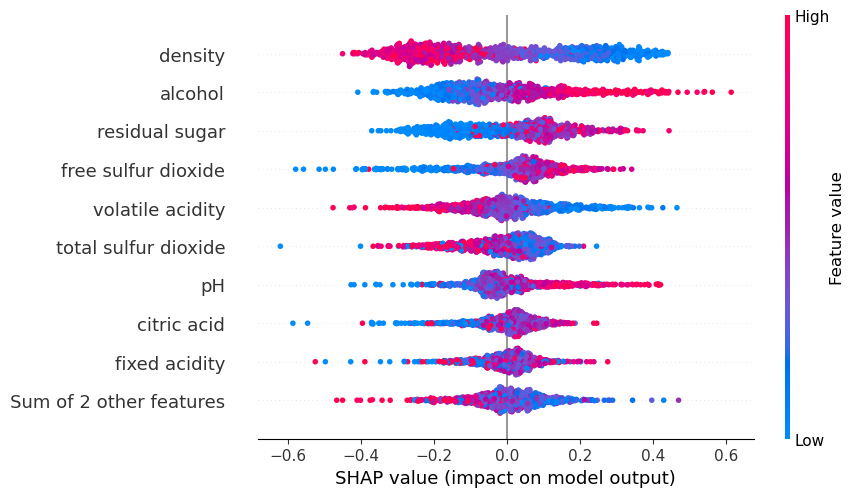

In [24]:
shap.plots.beeswarm(shap_values)

In [25]:
total_end_time = time.time()

In [26]:
total_time = (total_end_time - total_start_time) / 60
print(f'It took {total_time:.2f} minutes for this notebook to run.')

It took 170.45 minutes for this notebook to run.
